# 06. 입양 확률 예측 모델

**목적:** 개체 수준에서 입양 확률을 예측하고, SHAP으로 변수 중요도를 해석하여 정책 우선순위 도출

**입력:** `02_outputs/data/shelter_animals_enhanced.csv` (789,874행)

**타겟:** `입양여부` (0/1 이진 분류, 31.2% vs 68.8%)

**분할:** 시간 기반 — Train 2019~2023 / Test 2024

**목표:** ROC-AUC >= 0.70, Recall >= 0.60

In [1]:
# ============================================================
# 환경 설정
# ============================================================
import os
import warnings
import pickle
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, recall_score, f1_score,
                             classification_report, confusion_matrix,
                             roc_curve, precision_recall_curve, average_precision_score)
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
import lightgbm as lgb
import shap

# 한글 폰트 설정
matplotlib.rcParams['font.family'] = 'Apple SD Gothic Neo'
matplotlib.rcParams['axes.unicode_minus'] = False

# 경로 설정
BASE_DIR = os.path.dirname(os.getcwd())
OUT_DIR = os.path.join(BASE_DIR, '02_outputs', 'data')
FIG_DIR = os.path.join(BASE_DIR, '02_outputs', 'figures', 'modeling')
MODEL_DIR = os.path.join(BASE_DIR, '06_models')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f'BASE_DIR: {BASE_DIR}')

BASE_DIR: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound


## 1. 데이터 로드 및 필터링

In [2]:
raw = pd.read_csv(os.path.join(OUT_DIR, 'shelter_animals_enhanced.csv'))
print(f'원본: {raw.shape}')

# 2025년 제외, 개/고양이만
df = raw[(raw['접수년도'] != 2025) & (raw['동물종류'].isin(['개', '고양이']))].copy()
print(f'필터링 후 (2019-2024, 개/고양이): {df.shape}')
print(f'\n접수년도 분포:\n{df["접수년도"].value_counts().sort_index()}')
print(f'\n타겟 분포:\n{df["입양여부"].value_counts(normalize=True).round(4)}')

원본: (789874, 32)
필터링 후 (2019-2024, 개/고양이): (682010, 32)

접수년도 분포:
접수년도
2019    127519
2020    123264
2021    113179
2022    108938
2023    108317
2024    100793
Name: count, dtype: int64

타겟 분포:
입양여부
0    0.6914
1    0.3086
Name: proportion, dtype: float64


## 2. 피처 엔지니어링

In [3]:
# ============================================================
# 2.1 파생 변수 생성
# ============================================================

# 보호기간 클리핑 (99퍼센타일)
p99 = df['보호기간일'].quantile(0.99)
df['보호기간일_클리핑'] = df['보호기간일'].clip(upper=p99)
print(f'보호기간일 99퍼센타일: {p99}')

# 지역유형 (광역시 vs 도)
광역시 = ['서울특별시', '부산광역시', '대구광역시', '인천광역시', '광주광역시',
       '대전광역시', '울산광역시', '세종특별자치시']
df['지역유형'] = df['시도'].apply(lambda x: '광역시' if x in 광역시 else '도')

# 고령동물 (추정나이 8세 이상)
df['고령동물'] = (df['추정나이'] >= 8).astype(int)

# 소형동물 (체중 5kg 이하)
df['소형동물'] = (df['체중_정제'] <= 5).astype(int)

# 여름유기 (6~8월)
df['여름유기'] = df['접수월'].isin([6, 7, 8]).astype(int)

# 긍정/부정 성격점수
pos_cols = ['is_온순', 'is_활발', 'is_건강', 'is_친화']
neg_cols = ['is_겁많음', 'is_공격성', 'is_질병']
df['긍정성격점수'] = df[pos_cols].sum(axis=1)
df['부정성격점수'] = df[neg_cols].sum(axis=1)

print('파생 변수 생성 완료')
print(f'  지역유형: {df["지역유형"].value_counts().to_dict()}')
print(f'  고령동물 비율: {df["고령동물"].mean():.3f}')
print(f'  소형동물 비율: {df["소형동물"].mean():.3f}')

보호기간일 99퍼센타일: 15.0


파생 변수 생성 완료
  지역유형: {'도': 499804, '광역시': 182206}
  고령동물 비율: 0.035
  소형동물 비율: 0.671


In [4]:
# ============================================================
# 2.2 피처 선택
# ============================================================

# 범주형 (One-Hot)
cat_onehot = ['동물종류', '성별', '중성화 여부', '나이그룹', '체중그룹',
              '접수분기', '접수요일', '지역유형']

# 범주형 (Target Encoding) — 고차원
cat_target_enc = ['시도', '품종그룹', '색상_표준']

# 수치형
num_features = ['추정나이', '체중_정제', '보호기간일_클리핑', '접수년도', '접수월']

# 이진
bin_features = ['60일미만', 'is_온순', 'is_활발', 'is_건강', 'is_친화',
                'is_겁많음', 'is_공격성', 'is_질병',
                '고령동물', '소형동물', '여름유기']

# 파생 수치
derived_num = ['긍정성격점수', '부정성격점수']

target = '입양여부'

# 결측치 처리
df['추정나이'] = df['추정나이'].fillna(df['추정나이'].median())
df['체중_정제'] = df['체중_정제'].fillna(df['체중_정제'].median())
df['60일미만'] = df['60일미만'].astype(int)

print(f'피처 구성:')
print(f'  One-Hot 범주형: {len(cat_onehot)}개')
print(f'  Target Encoding 범주형: {len(cat_target_enc)}개')
print(f'  수치형: {len(num_features)}개')
print(f'  이진: {len(bin_features)}개')
print(f'  파생 수치: {len(derived_num)}개')

피처 구성:
  One-Hot 범주형: 8개
  Target Encoding 범주형: 3개
  수치형: 5개
  이진: 11개
  파생 수치: 2개


## 3. Train/Test 분할 (시간 기반)

In [5]:
train_df = df[df['접수년도'] <= 2023].copy()
test_df = df[df['접수년도'] == 2024].copy()

print(f'Train (2019-2023): {train_df.shape[0]:,}행')
print(f'Test  (2024):      {test_df.shape[0]:,}행')
print(f'\nTrain 타겟 분포: {train_df[target].value_counts(normalize=True).round(4).to_dict()}')
print(f'Test  타겟 분포: {test_df[target].value_counts(normalize=True).round(4).to_dict()}')

Train (2019-2023): 581,217행
Test  (2024):      100,793행

Train 타겟 분포: {0: 0.6848, 1: 0.3152}
Test  타겟 분포: {0: 0.7294, 1: 0.2706}


In [6]:
# ============================================================
# 3.1 Target Encoding (Train 기준으로 계산, Test에 적용)
# ============================================================
te_maps = {}
for col in cat_target_enc:
    te_map = train_df.groupby(col)[target].mean()
    global_mean = train_df[target].mean()
    te_maps[col] = te_map
    
    train_df[f'{col}_te'] = train_df[col].map(te_map).fillna(global_mean)
    test_df[f'{col}_te'] = test_df[col].map(te_map).fillna(global_mean)
    print(f'{col}: {te_map.nunique()}개 범주 → Target Encoding 완료')

te_features = [f'{col}_te' for col in cat_target_enc]

시도: 17개 범주 → Target Encoding 완료
품종그룹: 14개 범주 → Target Encoding 완료
색상_표준: 11개 범주 → Target Encoding 완료


In [7]:
# ============================================================
# 3.2 One-Hot Encoding
# ============================================================
train_ohe = pd.get_dummies(train_df[cat_onehot], drop_first=True)
test_ohe = pd.get_dummies(test_df[cat_onehot], drop_first=True)

# Train에 있는 컬럼 기준으로 맞추기
test_ohe = test_ohe.reindex(columns=train_ohe.columns, fill_value=0)

print(f'One-Hot 인코딩 후 컬럼 수: {train_ohe.shape[1]}')

One-Hot 인코딩 후 컬럼 수: 26


In [8]:
# ============================================================
# 3.3 최종 피처 행렬 구성
# ============================================================
all_num = num_features + bin_features + derived_num + te_features

X_train = pd.concat([train_df[all_num].reset_index(drop=True),
                      train_ohe.reset_index(drop=True)], axis=1)
X_test = pd.concat([test_df[all_num].reset_index(drop=True),
                     test_ohe.reset_index(drop=True)], axis=1)

y_train = train_df[target].reset_index(drop=True)
y_test = test_df[target].reset_index(drop=True)

# bool → int 변환
for col in X_train.columns:
    if X_train[col].dtype == 'bool':
        X_train[col] = X_train[col].astype(int)
        X_test[col] = X_test[col].astype(int)

# 결측치 최종 처리
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'y_train 분포: {y_train.value_counts().to_dict()}')
print(f'y_test  분포: {y_test.value_counts().to_dict()}')
print(f'\n피처 목록 ({X_train.shape[1]}개):')
print(list(X_train.columns))

X_train: (581217, 47)
X_test:  (100793, 47)
y_train 분포: {0: 398036, 1: 183181}
y_test  분포: {0: 73520, 1: 27273}

피처 목록 (47개):
['추정나이', '체중_정제', '보호기간일_클리핑', '접수년도', '접수월', '60일미만', 'is_온순', 'is_활발', 'is_건강', 'is_친화', 'is_겁많음', 'is_공격성', 'is_질병', '고령동물', '소형동물', '여름유기', '긍정성격점수', '부정성격점수', '시도_te', '품종그룹_te', '색상_표준_te', '접수분기', '동물종류_고양이', '성별_수컷', '성별_암컷', '중성화 여부_중성화 O', '중성화 여부_중성화 X', '나이그룹_1세 이하', '나이그룹_2-3세', '나이그룹_4-5세', '나이그룹_6-7세', '나이그룹_60일미만', '나이그룹_8-10세', '나이그룹_미상', '체중그룹_2-5kg', '체중그룹_20-30kg', '체중그룹_2kg 이하', '체중그룹_30kg 초과', '체중그룹_5-10kg', '체중그룹_미상', '접수요일_Monday', '접수요일_Saturday', '접수요일_Sunday', '접수요일_Thursday', '접수요일_Tuesday', '접수요일_Wednesday', '지역유형_도']


## 4. 모델 학습 및 비교

In [9]:
# ============================================================
# 4.1 베이스라인 및 비교 모델 학습
# ============================================================
# 클래스 비율 계산
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f'클래스 비율 (neg/pos): {scale_pos_weight:.2f}')

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE,
        n_jobs=-1, max_depth=15
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE, n_jobs=-1, max_depth=6,
        learning_rate=0.1, eval_metric='auc', verbosity=0
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200, scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE, n_jobs=-1, max_depth=8,
        learning_rate=0.1, verbose=-1
    )
}

results = []
trained_models = {}

for name, model in models.items():
    print(f'\n--- {name} 학습 중 ---')
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    auc = roc_auc_score(y_test, y_prob)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({'모델': name, 'ROC-AUC': auc, 'Recall': rec, 'F1': f1})
    print(f'  ROC-AUC: {auc:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}')

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print('\n=== 모델 비교 결과 ===')
display(results_df)

클래스 비율 (neg/pos): 2.17

--- Logistic Regression 학습 중 ---


  ROC-AUC: 0.6372 | Recall: 0.6136 | F1: 0.4474

--- Random Forest 학습 중 ---


  ROC-AUC: 0.6961 | Recall: 0.5394 | F1: 0.4779

--- XGBoost 학습 중 ---


  ROC-AUC: 0.7046 | Recall: 0.5577 | F1: 0.4878

--- LightGBM 학습 중 ---


  ROC-AUC: 0.7027 | Recall: 0.5516 | F1: 0.4856

=== 모델 비교 결과 ===


,모델,ROC-AUC,Recall,F1
2,XGBoost,0.704567,0.557658,0.487843
3,LightGBM,0.702667,0.551644,0.485636
1,Random Forest,0.696124,0.539398,0.477886
0,Logistic Regression,0.637214,0.613574,0.447433


In [10]:
# 최적 모델 선택
best_name = results_df.iloc[0]['모델']
print(f'최적 모델: {best_name}')
print(f'  ROC-AUC: {results_df.iloc[0]["ROC-AUC"]:.4f}')
print(f'  Recall:  {results_df.iloc[0]["Recall"]:.4f}')
print(f'  F1:      {results_df.iloc[0]["F1"]:.4f}')

최적 모델: XGBoost
  ROC-AUC: 0.7046
  Recall:  0.5577
  F1:      0.4878


## 5. 하이퍼파라미터 튜닝 (최적 모델)

In [11]:
# ============================================================
# LightGBM 기반 RandomizedSearchCV
# (최적 모델이 LightGBM이 아니더라도 LightGBM으로 튜닝 — 속도/성능 균형)
# ============================================================
param_dist = {
    'n_estimators': [300, 500, 700],
    'max_depth': [6, 8, 10, 12],
    'learning_rate': [0.05, 0.1, 0.15],
    'num_leaves': [31, 50, 70],
    'min_child_samples': [20, 50, 100],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [0, 0.1, 1.0]
}

lgbm_base = lgb.LGBMClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

search = RandomizedSearchCV(
    lgbm_base, param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print('RandomizedSearchCV 시작 (30회 × 5-Fold)...')
search.fit(X_train, y_train)

print(f'\n최적 파라미터:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\n최적 CV ROC-AUC: {search.best_score_:.4f}')

RandomizedSearchCV 시작 (30회 × 5-Fold)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits



최적 파라미터:
  subsample: 0.7
  reg_lambda: 0.1
  reg_alpha: 1.0
  num_leaves: 31
  n_estimators: 500
  min_child_samples: 100
  max_depth: 6
  learning_rate: 0.15
  colsample_bytree: 0.7

최적 CV ROC-AUC: 0.5856


In [12]:
# 튜닝된 모델로 Test 평가
final_model = search.best_estimator_
y_prob_final = final_model.predict_proba(X_test)[:, 1]
y_pred_final = final_model.predict(X_test)

auc_final = roc_auc_score(y_test, y_prob_final)
rec_final = recall_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final)

print('=== 튜닝된 LightGBM 최종 성능 ===')
print(f'ROC-AUC: {auc_final:.4f}')
print(f'Recall:  {rec_final:.4f}')
print(f'F1:      {f1_final:.4f}')
print(f'\n목표 달성 여부:')
print(f'  ROC-AUC >= 0.70: {"✓" if auc_final >= 0.70 else "✗"} ({auc_final:.4f})')
print(f'  Recall  >= 0.60: {"✓" if rec_final >= 0.60 else "✗"} ({rec_final:.4f})')
print(f'\n{classification_report(y_test, y_pred_final, target_names=["미입양", "입양"])}')

=== 튜닝된 LightGBM 최종 성능 ===
ROC-AUC: 0.7070
Recall:  0.5573
F1:      0.4912

목표 달성 여부:
  ROC-AUC >= 0.70: ✓ (0.7070)
  Recall  >= 0.60: ✗ (0.5573)

              precision    recall  f1-score   support

         미입양       0.82      0.74      0.77     73520
          입양       0.44      0.56      0.49     27273

    accuracy                           0.69    100793
   macro avg       0.63      0.65      0.63    100793
weighted avg       0.72      0.69      0.70    100793



## 6. 최종 평가 시각화

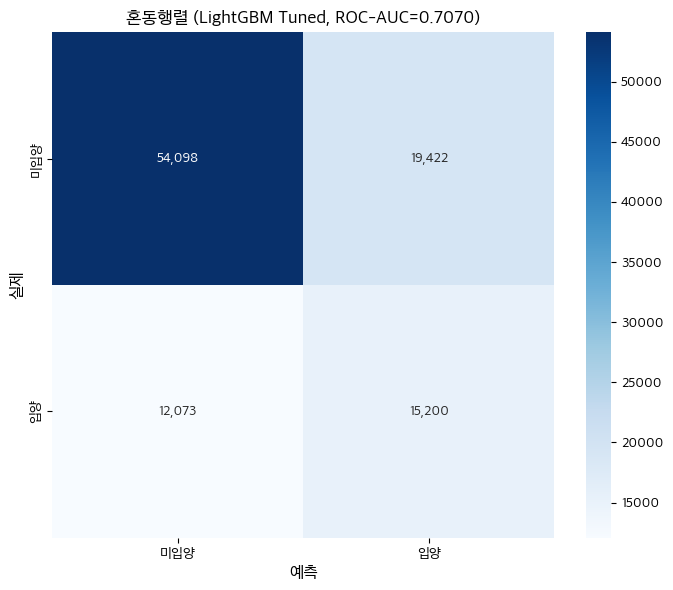

In [13]:
# ============================================================
# 6.1 혼동행렬
# ============================================================
cm = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['미입양', '입양'], yticklabels=['미입양', '입양'], ax=ax)
ax.set_xlabel('예측', fontsize=12)
ax.set_ylabel('실제', fontsize=12)
ax.set_title(f'혼동행렬 (LightGBM Tuned, ROC-AUC={auc_final:.4f})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

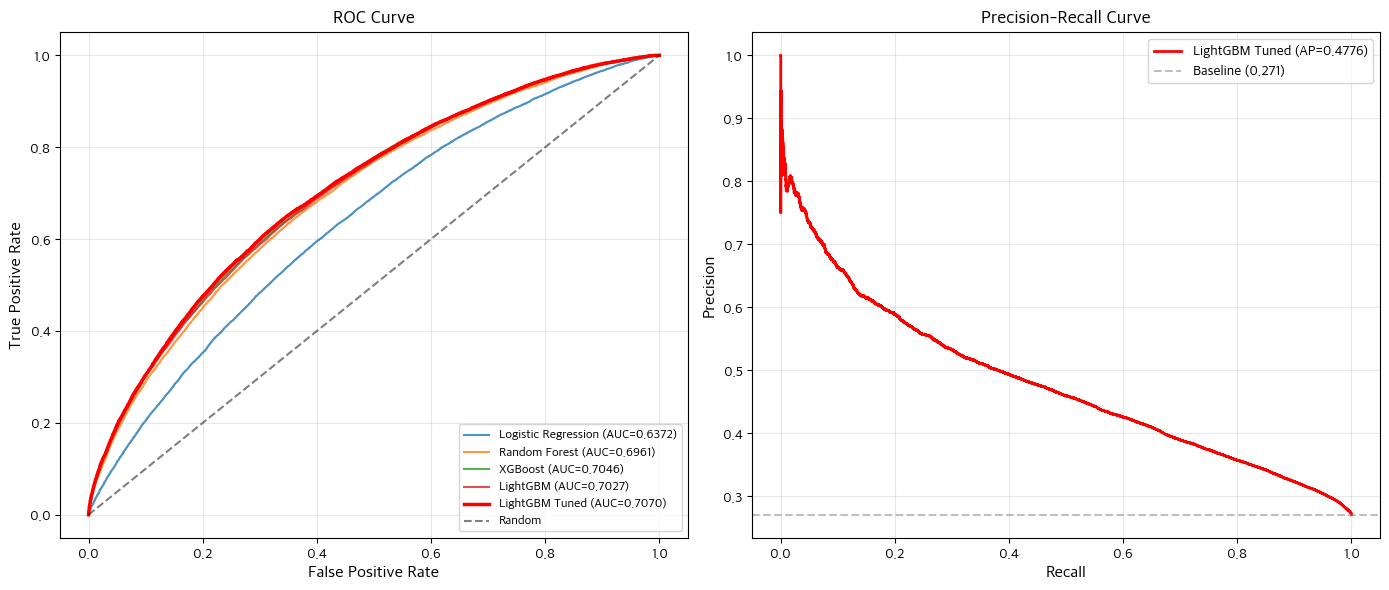

In [14]:
# ============================================================
# 6.2 ROC Curve (전 모델 비교 + 튜닝 모델)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
ax = axes[0]
for name, model in trained_models.items():
    y_prob_m = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob_m)
    auc_m = roc_auc_score(y_test, y_prob_m)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_m:.4f})', alpha=0.8)

# 튜닝 모델 추가
fpr_f, tpr_f, _ = roc_curve(y_test, y_prob_final)
ax.plot(fpr_f, tpr_f, label=f'LightGBM Tuned (AUC={auc_final:.4f})',
        linewidth=2.5, color='red')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)

# PR Curve
ax = axes[1]
precision_f, recall_f, _ = precision_recall_curve(y_test, y_prob_final)
ap = average_precision_score(y_test, y_prob_final)
ax.plot(recall_f, precision_f, color='red', linewidth=2,
        label=f'LightGBM Tuned (AP={ap:.4f})')
ax.axhline(y=y_test.mean(), color='gray', linestyle='--', alpha=0.5, label=f'Baseline ({y_test.mean():.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'roc_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. SHAP 분석

In [15]:
# ============================================================
# 7.1 SHAP 값 계산 (Test set 1만건 샘플링)
# ============================================================
SHAP_SAMPLE = 10000
idx = np.random.choice(len(X_test), size=min(SHAP_SAMPLE, len(X_test)), replace=False)
X_shap = X_test.iloc[idx]

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap)

# LightGBM binary → shap_values가 리스트인 경우 양성 클래스 선택
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f'SHAP 값 shape: {shap_values.shape}')
print(f'샘플 수: {X_shap.shape[0]}')

SHAP 값 shape: (10000, 47)
샘플 수: 10000


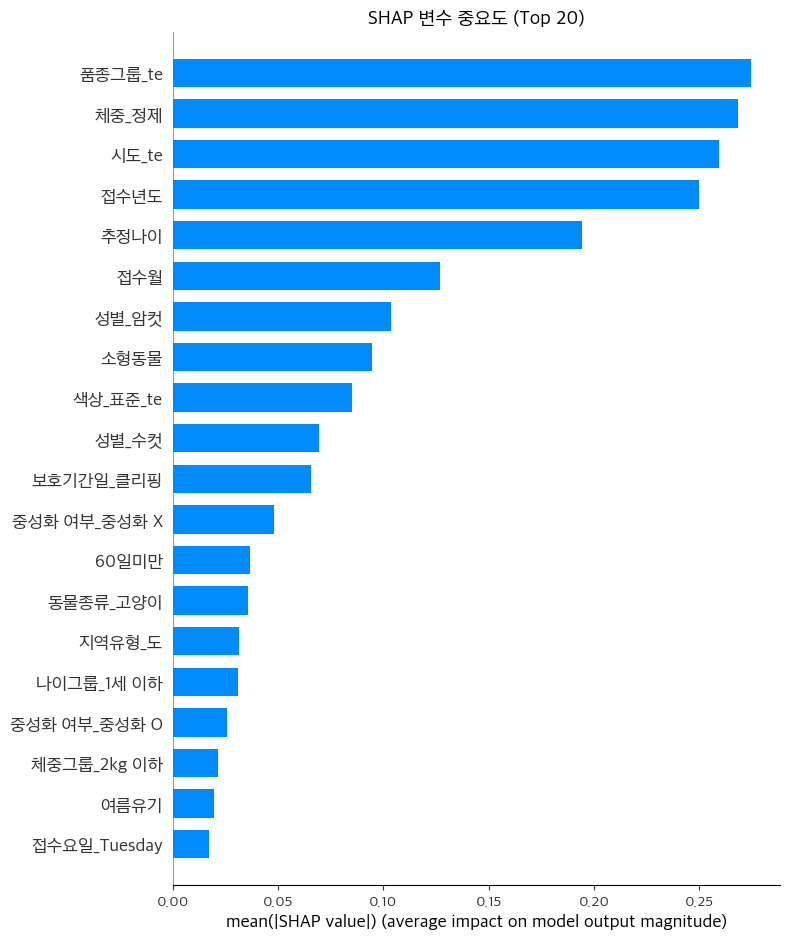

In [16]:
# ============================================================
# 7.2 Summary Bar Plot (전역 변수 중요도)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, plot_type='bar',
                  max_display=20, show=False)
plt.title('SHAP 변수 중요도 (Top 20)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_summary_bar.png'), dpi=150, bbox_inches='tight')
plt.show()

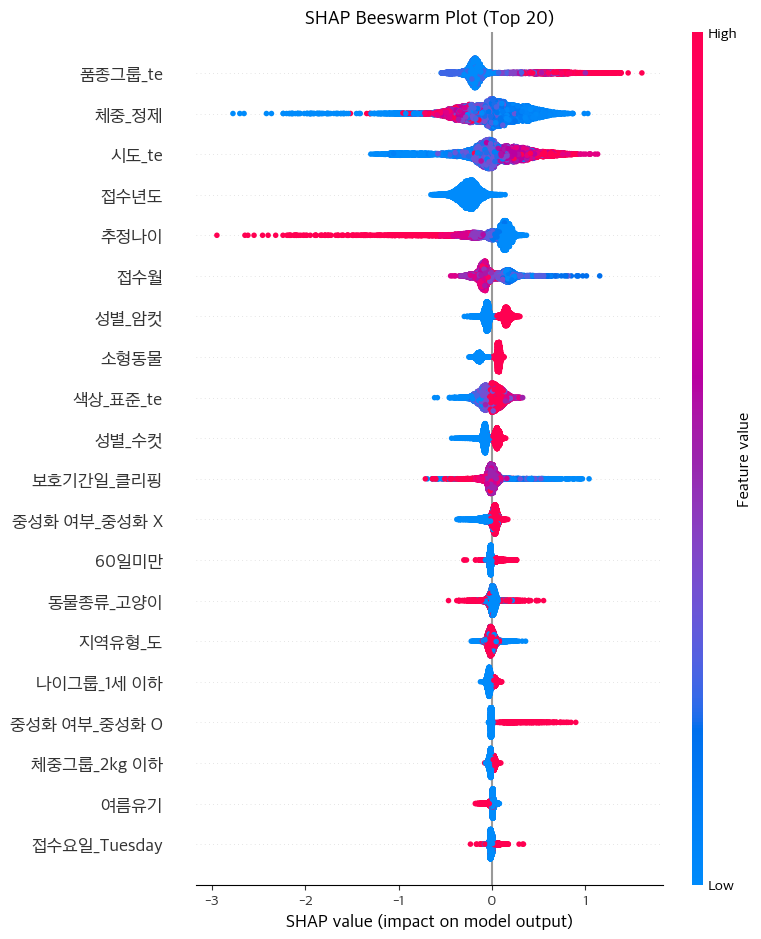

In [17]:
# ============================================================
# 7.3 Beeswarm Plot (변수별 영향 방향)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
plt.title('SHAP Beeswarm Plot (Top 20)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_summary_beeswarm.png'), dpi=150, bbox_inches='tight')
plt.show()

SHAP 상위 5개 변수:
품종그룹_te    0.2746
체중_정제      0.2686
시도_te      0.2593
접수년도       0.2497
추정나이       0.1942
dtype: float64


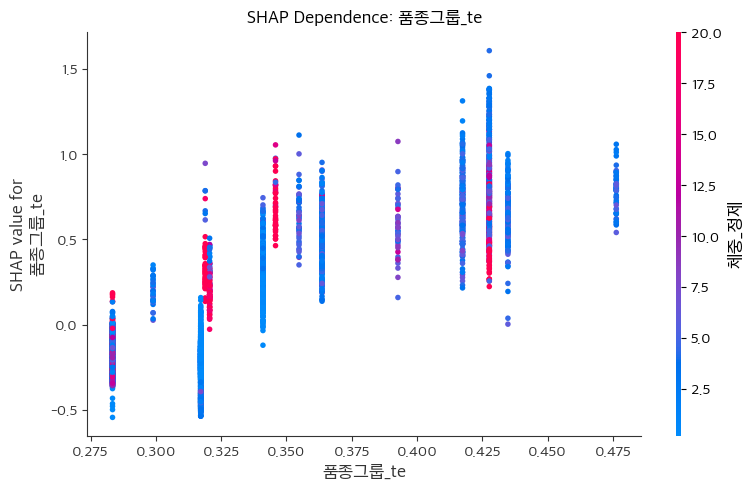

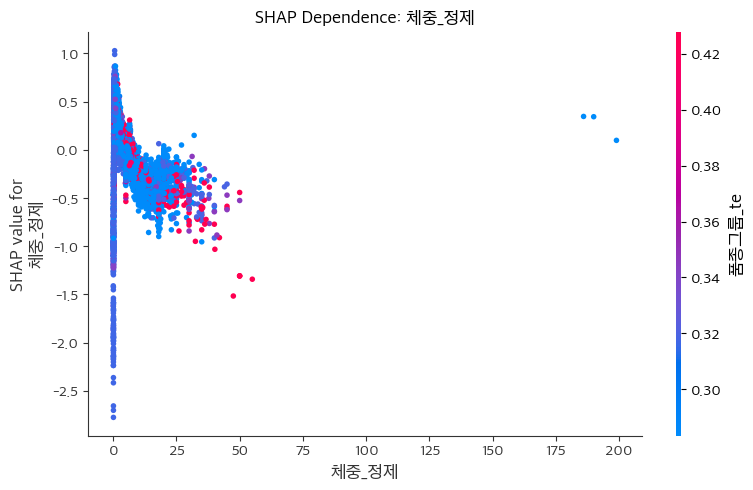

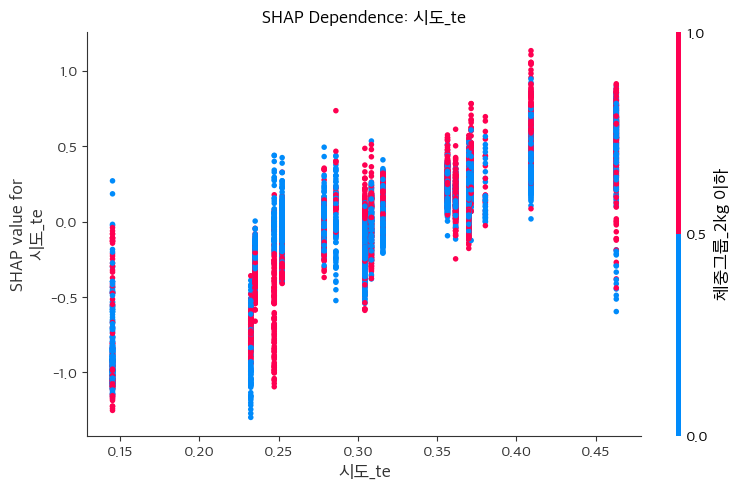

In [18]:
# ============================================================
# 7.4 Dependence Plot (주요 변수)
# ============================================================
# 상위 중요 변수 확인
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_features = pd.Series(mean_abs_shap, index=X_shap.columns).nlargest(5)
print('SHAP 상위 5개 변수:')
print(top_features.round(4))

# 상위 3개 변수에 대한 Dependence Plot
for feat in top_features.index[:3]:
    fig, ax = plt.subplots(figsize=(8, 5))
    shap.dependence_plot(feat, shap_values, X_shap, show=False, ax=ax)
    ax.set_title(f'SHAP Dependence: {feat}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    safe_name = feat.replace(' ', '_').replace('/', '_')
    plt.savefig(os.path.join(FIG_DIR, f'shap_dependence_{safe_name}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

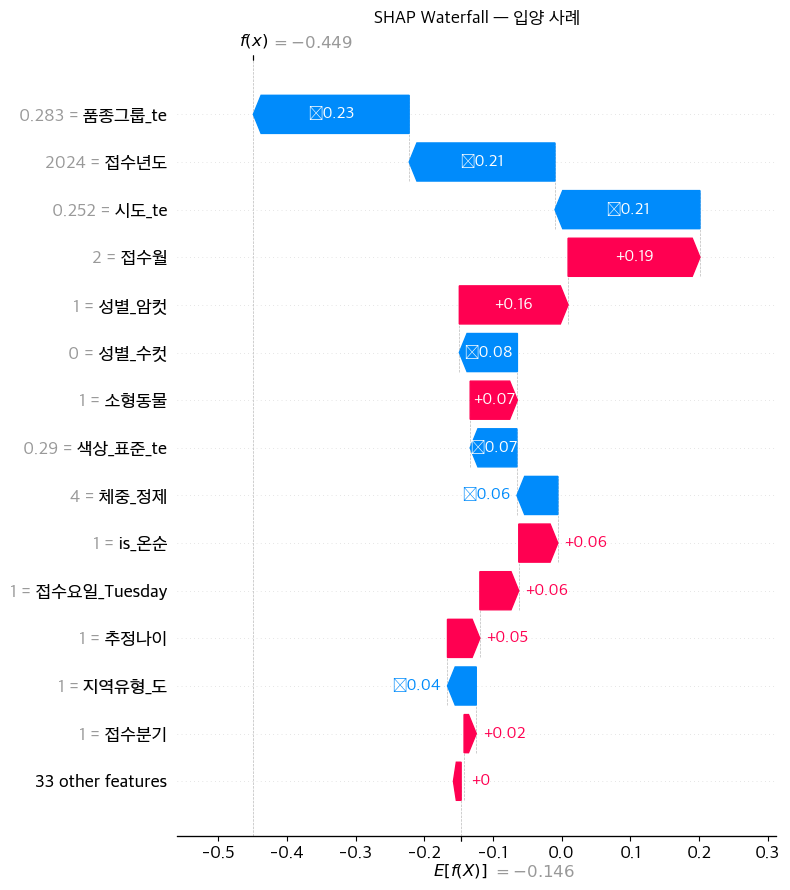

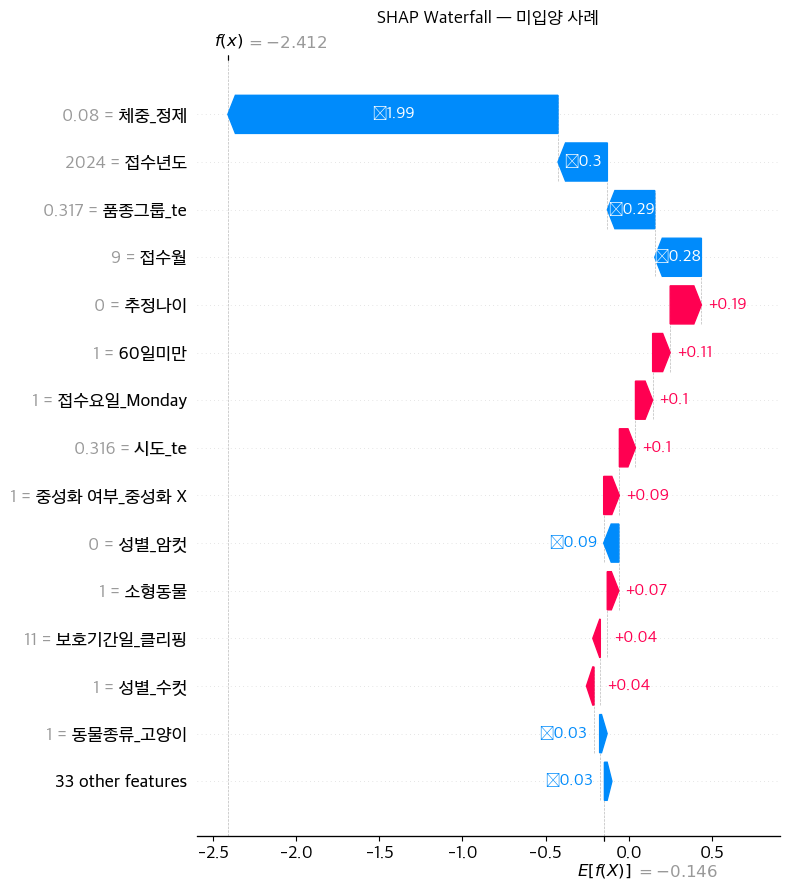


SHAP 분석 완료


In [19]:
# ============================================================
# 7.5 Waterfall Plot (개별 예측 해석)
# ============================================================
# 입양된 개체 1개, 미입양 개체 1개
y_shap = y_test.iloc[idx]
adopted_idx = np.where(y_shap == 1)[0]
not_adopted_idx = np.where(y_shap == 0)[0]

cases = []
if len(adopted_idx) > 0:
    cases.append(('입양 사례', adopted_idx[0]))
if len(not_adopted_idx) > 0:
    cases.append(('미입양 사례', not_adopted_idx[0]))

for title, i in cases:
    ev = shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value if not isinstance(explainer.expected_value, list) else explainer.expected_value[1],
        data=X_shap.iloc[i].values,
        feature_names=X_shap.columns.tolist()
    )
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.waterfall_plot(ev, max_display=15, show=False)
    plt.title(f'SHAP Waterfall — {title}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('\nSHAP 분석 완료')

## 8. 정책 제언

SHAP 결과 기반으로 입양률 향상을 위한 정책 우선순위를 도출한다.

In [20]:
# SHAP 기반 변수 중요도 정리
importance = pd.DataFrame({
    '변수': X_shap.columns,
    'SHAP_평균절대값': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_평균절대값', ascending=False)

print('=== SHAP 변수 중요도 Top 15 ===')
display(importance.head(15).reset_index(drop=True))

print('\n=== 정책 제언 ===')
print('1. 가장 영향력 있는 변수들을 기반으로 한 개입 전략:')
for i, row in importance.head(5).iterrows():
    feat = row['변수']
    imp = row['SHAP_평균절대값']
    # 변수에 따른 제언
    if '나이' in feat or '추정나이' in feat:
        advice = '→ 고령동물 특별 입양 프로그램, 시니어 동물 입양 인센티브'
    elif '체중' in feat:
        advice = '→ 대형견 입양 인식 개선 캠페인'
    elif '보호기간' in feat:
        advice = '→ 조기 입양 매칭 시스템 도입, 보호 초기 집중 홍보'
    elif '품종' in feat:
        advice = '→ 믹스견/묘 입양 인식 개선, 품종 편향 해소 캠페인'
    elif '성격' in feat or 'is_' in feat:
        advice = '→ 성격 프로필 카드 제작, 입양자-동물 매칭 시스템'
    elif '시도' in feat or '지역' in feat:
        advice = '→ 저입양률 지역 타겟 입양 행사, 교차 지역 입양 네트워크'
    elif '중성화' in feat:
        advice = '→ 보호소 내 중성화 수술 지원 강화'
    elif '접수' in feat or '년도' in feat or '월' in feat:
        advice = '→ 비수기 입양 캠페인 강화'
    else:
        advice = '→ 추가 분석 필요'
    print(f'  [{i+1}] {feat} (SHAP={imp:.4f}) {advice}')

=== SHAP 변수 중요도 Top 15 ===


,변수,SHAP_평균절대값
0,품종그룹_te,0.274607
1,체중_정제,0.268620
2,시도_te,0.259305
3,접수년도,0.249712
4,추정나이,0.194170
5,접수월,0.126901
6,성별_암컷,0.103593
7,소형동물,0.094624
8,색상_표준_te,0.085170
9,성별_수컷,0.069676



=== 정책 제언 ===
1. 가장 영향력 있는 변수들을 기반으로 한 개입 전략:
  [20] 품종그룹_te (SHAP=0.2746) → 믹스견/묘 입양 인식 개선, 품종 편향 해소 캠페인
  [2] 체중_정제 (SHAP=0.2686) → 대형견 입양 인식 개선 캠페인
  [19] 시도_te (SHAP=0.2593) → 저입양률 지역 타겟 입양 행사, 교차 지역 입양 네트워크
  [4] 접수년도 (SHAP=0.2497) → 비수기 입양 캠페인 강화
  [1] 추정나이 (SHAP=0.1942) → 고령동물 특별 입양 프로그램, 시니어 동물 입양 인센티브


## 9. 결과 저장

In [21]:
# ============================================================
# 9.1 모델 저장
# ============================================================
model_path = os.path.join(MODEL_DIR, 'lgbm_adoption_classifier.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(final_model, f)
print(f'모델 저장: {model_path}')

# ============================================================
# 9.2 예측 결과 CSV 저장
# ============================================================
pred_df = test_df[['접수일자', '동물종류', '품종그룹', '시도', '보호소명', '입양여부']].copy()
pred_df = pred_df.reset_index(drop=True)
pred_df['예측확률'] = y_prob_final
pred_df['예측결과'] = y_pred_final
pred_df.to_csv(os.path.join(OUT_DIR, 'adoption_predictions.csv'),
               index=False, encoding='utf-8-sig')
print(f'예측 결과 저장: {os.path.join(OUT_DIR, "adoption_predictions.csv")}')

print(f'\n저장된 시각화:')
for f_name in sorted(os.listdir(FIG_DIR)):
    print(f'  {os.path.join(FIG_DIR, f_name)}')

모델 저장: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/06_models/lgbm_adoption_classifier.pkl
예측 결과 저장: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/data/adoption_predictions.csv

저장된 시각화:
  /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/modeling/confusion_matrix.png
  /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/modeling/roc_curve.png
  /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/modeling/shap_dependence_시도_te.png
  /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/modeling/shap_dependence_체중_정제.png
  /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/modeling/shap_dependence_품종그룹_te.png
  /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/modeling/shap_summary_bar.png
  /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_

In [22]:
# ============================================================
# 최종 요약
# ============================================================
print('=' * 60)
print('입양 확률 예측 모델 — 최종 요약')
print('=' * 60)
print(f'학습 데이터: 2019-2023 ({len(X_train):,}행)')
print(f'테스트 데이터: 2024 ({len(X_test):,}행)')
print(f'피처 수: {X_train.shape[1]}')
print(f'\n--- 튜닝 전 모델 비교 ---')
for _, row in results_df.iterrows():
    print(f'  {row["모델"]:25s} AUC={row["ROC-AUC"]:.4f}  Recall={row["Recall"]:.4f}  F1={row["F1"]:.4f}')
print(f'\n--- 최종 모델 (LightGBM Tuned) ---')
print(f'  ROC-AUC: {auc_final:.4f}')
print(f'  Recall:  {rec_final:.4f}')
print(f'  F1:      {f1_final:.4f}')
print(f'\n--- SHAP Top 5 변수 ---')
for _, row in importance.head(5).iterrows():
    print(f'  {row["변수"]:25s} SHAP={row["SHAP_평균절대값"]:.4f}')

입양 확률 예측 모델 — 최종 요약
학습 데이터: 2019-2023 (581,217행)
테스트 데이터: 2024 (100,793행)
피처 수: 47

--- 튜닝 전 모델 비교 ---
  XGBoost                   AUC=0.7046  Recall=0.5577  F1=0.4878
  LightGBM                  AUC=0.7027  Recall=0.5516  F1=0.4856
  Random Forest             AUC=0.6961  Recall=0.5394  F1=0.4779
  Logistic Regression       AUC=0.6372  Recall=0.6136  F1=0.4474

--- 최종 모델 (LightGBM Tuned) ---
  ROC-AUC: 0.7070
  Recall:  0.5573
  F1:      0.4912

--- SHAP Top 5 변수 ---
  품종그룹_te                   SHAP=0.2746
  체중_정제                     SHAP=0.2686
  시도_te                     SHAP=0.2593
  접수년도                      SHAP=0.2497
  추정나이                      SHAP=0.1942
